In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
import warnings
warnings.filterwarnings('ignore')
# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/satyamsatyarthi2006/titanic-survival/Titanic-Dataset.xls')

# ── CLEAN ─────────────────────────────────────────────────────────────────────
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# ── ENCODE ────────────────────────────────────────────────────────────────────
le = LabelEncoder()
df['Sex']      = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

for col in ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']:
    df[col] = df[col].astype(int)

# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Age_bin']    = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                          labels=[0,1,2,3,4]).astype(int)
df.drop(columns=['SibSp', 'Parch', 'Age'], inplace=True)

print("Shape:", df.shape)
print(df.head())

Shape: (891, 8)
   Survived  Pclass  Sex     Fare  Embarked  FamilySize  IsAlone  Age_bin
0         0       3    1   7.2500         2           2        0        2
1         1       1    0  71.2833         0           2        0        3
2         1       3    0   7.9250         2           1        1        2
3         1       1    0  53.1000         2           2        0        2
4         0       3    1   8.0500         2           1        1        2


In [2]:
X = df.drop('Survived', axis=1)
y = df['Survived']

# KNN is distance-based — scaling is CRITICAL
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# feature selection
X_mm = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_mm, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print(feat_scores.to_string(index=False))

drop_cols = feat_scores[feat_scores['P-value'] > 0.05]['Feature'].tolist()
X_scaled  = X_scaled.drop(columns=drop_cols)
print("Final features:", X_scaled.columns.tolist())

   Feature     Score      P-value
       Sex 92.702447 6.077838e-22
    Pclass 27.232933 1.803602e-07
   IsAlone 14.640793 1.300685e-04
      Fare  8.819172 2.980820e-03
  Embarked  5.101262 2.390844e-02
   Age_bin  0.669997 4.130528e-01
FamilySize  0.070909 7.900177e-01
Final features: ['Pclass', 'Sex', 'Fare', 'Embarked', 'IsAlone']


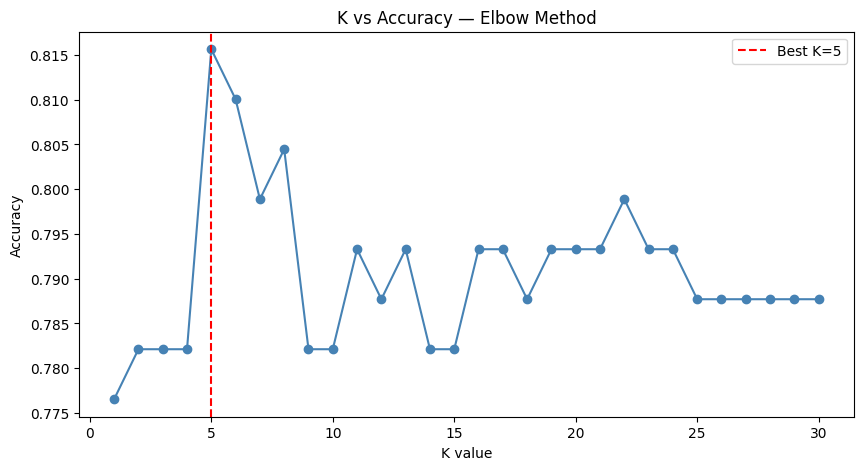

Best K: 5 → Accuracy: 0.8156


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_final = X_scaled
y_final = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# try k from 1 to 30 and plot accuracy
k_scores = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    k_scores.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), k_scores, marker='o', color='steelblue')
plt.axvline(x=k_scores.index(max(k_scores))+1, color='red', 
            linestyle='--', label=f'Best K={k_scores.index(max(k_scores))+1}')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy — Elbow Method')
plt.legend()
plt.show()

best_k = k_scores.index(max(k_scores)) + 1
print(f"Best K: {best_k} → Accuracy: {max(k_scores):.4f}")

In [4]:
# manual KNN to show what sklearn does internally
test_point = X_test.iloc[0].values  # pick one test passenger

# step 1 — calculate euclidean distance to all training points
distances = np.sqrt(((X_train.values - test_point) ** 2).sum(axis=1))

# step 2 — sort and take K nearest
k = best_k
nearest_indices = np.argsort(distances)[:k]
nearest_labels  = y_train.iloc[nearest_indices].values

# step 3 — majority vote
prediction = np.bincount(nearest_labels).argmax()

print(f"Distances (first 5 sorted): {np.sort(distances)[:5].round(3)}")
print(f"Nearest {k} labels        : {nearest_labels}")
print(f"Manual prediction          : {prediction}")
print(f"Actual label               : {y_test.iloc[0]}")

Distances (first 5 sorted): [0.01  0.016 0.081 0.13  0.135]
Nearest 5 labels        : [1 0 1 0 1]
Manual prediction          : 1
Actual label               : 1


Accuracy  : 0.8268
Precision : 0.8028
Recall    : 0.7703
F1 Score  : 0.7862


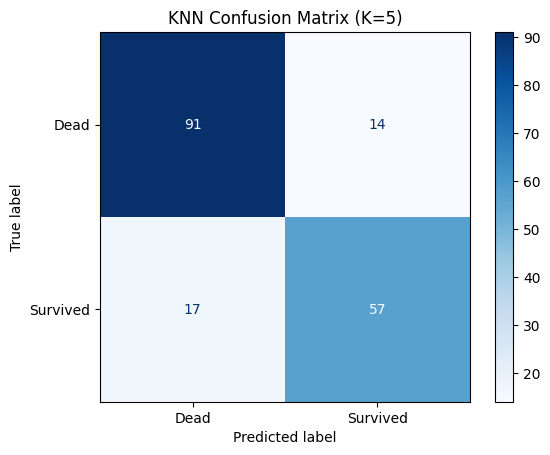


CV Accuracy: 0.7947 ± 0.0536
Each fold  : [0.6983 0.7809 0.8539 0.8146 0.8258]


In [5]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score

# train with best k
knn_final = KNeighborsClassifier(n_neighbors=best_k, 
                                  metric='euclidean',  # distance formula
                                  weights='distance')  # closer neighbors vote more
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

# metrics
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Dead', 'Survived']).plot(cmap='Blues')
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.show()

# cross validation
scores = cross_val_score(knn_final, X_final, y_final, cv=5, scoring='accuracy')
print(f"\nCV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Each fold  : {scores.round(4)}")